#  Online et stochastique pour les CNN

## Objectif TP4

Le TP4 demande de passer d'un cadre purement batch a un cadre plus sequentiel:

- en **online**, les exemples arrivent un par un et le modele est mis a jour apres chaque observation;
- en **stochastique**, on compare differentes granularites de mise a jour, de pas d'apprentissage et d'ordre de parcours des donnees.

L'objectif est de relier ces variantes au meme cadre CNN que dans les TP precedents, pour la regression et pour la classification binaire.


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader


from data_loader import create_dataloaders, resolve_default_paths
from experiment_spec import EXPERIMENTAL_FRAME
from train_common import (
    BinaryHingeLoss,
    build_model,
    evaluate_classification,
    evaluate_regression,
    select_device,
    set_seed,
    train_one_epoch,
)


In [2]:
defaults = resolve_default_paths()
device = select_device('auto')

MODEL_NAMES = ['simple', 'improved']

BASE_CONFIG = {
    'image_dir': defaults['image_dir'],
    'attr_file': defaults['attr_file'],
    'partition_file': defaults['partition_file'],
    'image_size': 64,
    'num_workers': 0,
    'seed': 42,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'augment': False,
}

ONLINE_LR_REGRESSION = 1e-3
ONLINE_LR_CLASSIFICATION = 1e-3
ONLINE_MAX_STEPS = 128
REFERENCE_EPOCHS = 2
PROJECTION_RADIUS = 25.0

STOCHASTIC_EPOCHS = 4
STOCHASTIC_WEIGHT_DECAY = 1e-4
POINT_BATCH_SIZE = 1
MINI_BATCH_SIZE = 32

for key in ['image_dir', 'attr_file']:
    print(key, '->', BASE_CONFIG[key], Path(BASE_CONFIG[key]).exists())
print('partition_file ->', BASE_CONFIG['partition_file'], Path(BASE_CONFIG['partition_file']).exists())
print('device ->', device)


image_dir -> data/img_align_celeba_reduced True
attr_file -> data/list_attr_celeba.csv True
partition_file -> data/list_eval_partition_reduced.csv True
device -> cpu


In [3]:
def get_loaders(task, batch_size):
    common_kwargs = dict(
        img_dir=BASE_CONFIG['image_dir'],
        attr_file=BASE_CONFIG['attr_file'],
        partition_file=BASE_CONFIG['partition_file'] if Path(BASE_CONFIG['partition_file']).exists() else None,
        batch_size=batch_size,
        image_size=BASE_CONFIG['image_size'],
        num_workers=BASE_CONFIG['num_workers'],
        seed=BASE_CONFIG['seed'],
        val_ratio=BASE_CONFIG['val_ratio'],
        test_ratio=BASE_CONFIG['test_ratio'],
        augment=BASE_CONFIG['augment'],
    )
    if task == 'regression':
        return create_dataloaders(target_type='regression', **common_kwargs)
    return create_dataloaders(
        target_type='classification',
        target_column=EXPERIMENTAL_FRAME['classification']['target_column'],
        classification_label_scheme=EXPERIMENTAL_FRAME['classification']['label_scheme'],
        **common_kwargs,
    )


def get_fixed_or_random_train_loader(task, batch_size, shuffle):
    loaders, dataset_sizes = get_loaders(task, batch_size=batch_size)
    train_dataset = loaders['train'].dataset
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=BASE_CONFIG['num_workers'],
        pin_memory=torch.cuda.is_available(),
    )
    loaders['train'] = train_loader
    return loaders, dataset_sizes


def project_parameters_l2(model, radius):
    if radius is None:
        return
    with torch.no_grad():
        total_norm_sq = 0.0
        for parameter in model.parameters():
            total_norm_sq += float(torch.sum(parameter.data ** 2).item())
        total_norm = math.sqrt(total_norm_sq)
        if total_norm <= radius or total_norm == 0.0:
            return
        scale = radius / total_norm
        for parameter in model.parameters():
            parameter.data.mul_(scale)


def build_reference_model(task, model_name, epochs=REFERENCE_EPOCHS):
    set_seed(BASE_CONFIG['seed'])
    loaders, _ = get_loaders(task, batch_size=MINI_BATCH_SIZE)
    model = build_model(model_name, task=task).to(device)

    if task == 'regression':
        criterion = nn.MSELoss()
    else:
        criterion = BinaryHingeLoss()

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=STOCHASTIC_WEIGHT_DECAY)
    for _ in range(epochs):
        train_one_epoch(model, loaders['train'], criterion, optimizer, device)
    model.eval()
    return model


def run_online_experiment(task, model_name, lr, max_steps, projection_radius=None):
    set_seed(BASE_CONFIG['seed'])
    loaders, dataset_sizes = get_fixed_or_random_train_loader(task, batch_size=1, shuffle=False)
    model = build_model(model_name, task=task).to(device)
    reference_model = build_reference_model(task, model_name)

    if task == 'regression':
        criterion = nn.MSELoss()
        evaluator = evaluate_regression
    else:
        criterion = BinaryHingeLoss()
        evaluator = evaluate_classification

    optimizer = optim.SGD(model.parameters(), lr=lr)
    history = []
    cumulative_loss = 0.0
    cumulative_reference_loss = 0.0

    for step, (inputs, targets) in enumerate(loaders['train'], start=1):
        if step > max_steps:
            break

        inputs = inputs.to(device)
        targets = targets.to(device).view(-1)

        with torch.no_grad():
            reference_outputs = reference_model(inputs).view(-1)
            reference_loss = criterion(reference_outputs, targets).item()

        optimizer.zero_grad()
        outputs = model(inputs).view(-1)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        project_parameters_l2(model, projection_radius)

        current_loss = float(loss.item())
        cumulative_loss += current_loss
        cumulative_reference_loss += float(reference_loss)
        regret = cumulative_loss - cumulative_reference_loss

        history.append({
            'step': step,
            'loss': current_loss,
            'reference_loss': float(reference_loss),
            'cumulative_loss': cumulative_loss,
            'cumulative_reference_loss': cumulative_reference_loss,
            'regret': regret,
        })

    val_metrics = evaluator(model, loaders['val'], criterion, device)
    test_metrics = evaluator(model, loaders['test'], criterion, device)
    return {
        'task': task,
        'model': model_name,
        'lr': lr,
        'max_steps': max_steps,
        'projection_radius': projection_radius,
        'dataset_sizes': dataset_sizes,
        'history': pd.DataFrame(history),
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
    }


def run_stochastic_experiment(task, model_name, batch_size, lr_mode, shuffle, epochs, base_lr):
    set_seed(BASE_CONFIG['seed'])
    loaders, dataset_sizes = get_fixed_or_random_train_loader(task, batch_size=batch_size, shuffle=shuffle)
    model = build_model(model_name, task=task).to(device)

    if task == 'regression':
        criterion = nn.MSELoss()
        evaluator = evaluate_regression
    else:
        criterion = BinaryHingeLoss()
        evaluator = evaluate_classification

    optimizer = optim.SGD(model.parameters(), lr=base_lr, weight_decay=STOCHASTIC_WEIGHT_DECAY)
    history = []

    for epoch in range(1, epochs + 1):
        if lr_mode == 'decay':
            current_lr = base_lr / math.sqrt(epoch)
        else:
            current_lr = base_lr
        for group in optimizer.param_groups:
            group['lr'] = current_lr

        train_loss = train_one_epoch(model, loaders['train'], criterion, optimizer, device)
        val_metrics = evaluator(model, loaders['val'], criterion, device)
        row = {
            'epoch': epoch,
            'lr': current_lr,
            'train_loss': train_loss,
            'val_loss': val_metrics['loss'],
        }
        if task == 'regression':
            row.update({
                'val_mae': val_metrics['mae'],
                'val_rmse': val_metrics['rmse'],
                'val_r2': val_metrics['r2'],
            })
        else:
            row.update({
                'val_accuracy': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
            })
        history.append(row)

    test_metrics = evaluator(model, loaders['test'], criterion, device)
    return {
        'task': task,
        'model': model_name,
        'batch_size': batch_size,
        'lr_mode': lr_mode,
        'shuffle': shuffle,
        'epochs': epochs,
        'base_lr': base_lr,
        'dataset_sizes': dataset_sizes,
        'history': pd.DataFrame(history),
        'test_metrics': test_metrics,
    }


def summarize_stochastic(results, task):
    rows = []
    for item in results:
        last = item['history'].iloc[-1].to_dict()
        row = {
            'model': item['model'],
            'batch_size': item['batch_size'],
            'lr_mode': item['lr_mode'],
            'order': 'random' if item['shuffle'] else 'fixed',
            'base_lr': item['base_lr'],
            'final_val_loss': last['val_loss'],
            'test_loss': item['test_metrics']['loss'],
        }
        if task == 'regression':
            row.update({
                'final_val_rmse': last['val_rmse'],
                'test_rmse': item['test_metrics']['rmse'],
                'test_r2': item['test_metrics']['r2'],
            })
        else:
            row.update({
                'final_val_f1': last['val_f1'],
                'test_f1': item['test_metrics']['f1'],
                'test_accuracy': item['test_metrics']['accuracy'],
            })
        rows.append(row)
    return pd.DataFrame(rows)


## Gradient en ligne pour la regression CNN

On considere une arrivee sequentielle des exemples, un exemple a la fois. A chaque pas:

1. on observe un exemple;
2. on calcule la perte de regression;
3. on met a jour le CNN;
4. on suit la perte cumulative et le regret.


In [4]:
online_regression_results = []

for model_name in MODEL_NAMES:
    print(f'[online regression] model={model_name}')
    result = run_online_experiment(
        task='regression',
        model_name=model_name,
        lr=ONLINE_LR_REGRESSION,
        max_steps=ONLINE_MAX_STEPS,
        projection_radius=PROJECTION_RADIUS,
    )
    online_regression_results.append(result)

for item in online_regression_results:
    display(item['history'].head())
    print(item['model'], item['val_metrics'], item['test_metrics'])


[online regression] model=simple
[online regression] model=improved


,step,loss,reference_loss,cumulative_loss,cumulative_reference_loss,regret
0,1,676.359070,28.744453,676.359070,28.744453,647.614616
1,2,564.615540,4.152761,1240.974609,32.897214,1208.077395
2,3,546.168640,1.516218,1787.143250,34.413432,1752.729818
3,4,194.132019,30.292900,1981.275269,64.706332,1916.568937
4,5,257.519043,8.632402,2238.794312,73.338734,2165.455577


simple {'loss': 103.74324413656235, 'mae': 8.597236633300781, 'mse': 103.74324035644531, 'rmse': 10.185442570475047, 'r2': -2.051530599594116} {'loss': 103.41272409811272, 'mae': 8.64283561706543, 'mse': 103.4127197265625, 'rmse': 10.169204478550055, 'r2': -2.1684370040893555}


,step,loss,reference_loss,cumulative_loss,cumulative_reference_loss,regret
0,1,667.668457,33.722080,667.668457,33.722080,633.946377
1,2,35.715309,24.420229,703.383766,58.142309,645.241457
2,3,9956.343750,1.014295,10659.727516,59.156604,10600.570912
3,4,258.342987,26.744640,10918.070503,85.901244,10832.169259
4,5,577.794556,41.213608,11495.865059,127.114852,11368.750207


improved {'loss': 34.24501606333256, 'mae': 4.861372947692871, 'mse': 34.24501419067383, 'rmse': 5.851923973418813, 'r2': -0.0072917938232421875} {'loss': 32.854237661778924, 'mae': 4.705783843994141, 'mse': 32.8542366027832, 'rmse': 5.7318615303218206, 'r2': -0.006613016128540039}


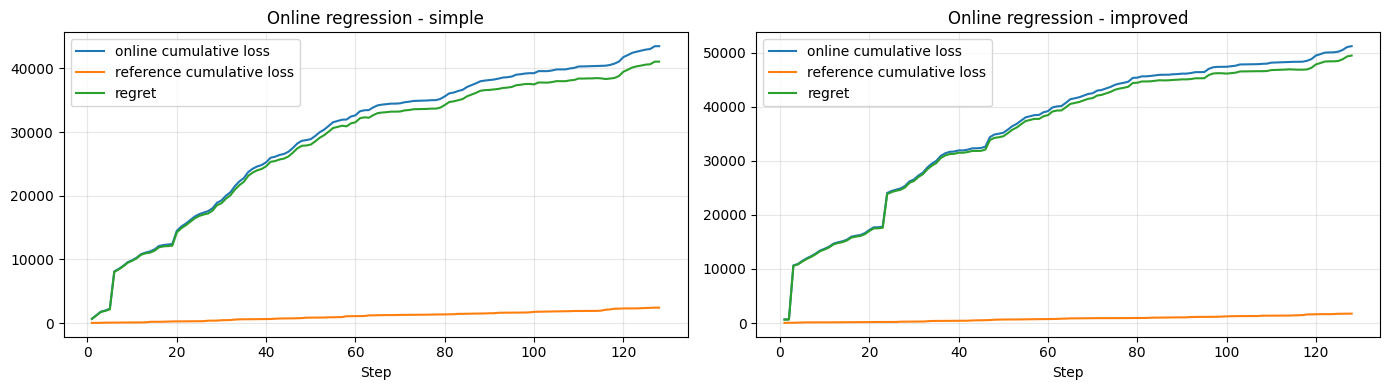

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, item in zip(axes, online_regression_results):
    history = item['history']
    ax.plot(history['step'], history['cumulative_loss'], label='online cumulative loss')
    ax.plot(history['step'], history['cumulative_reference_loss'], label='reference cumulative loss')
    ax.plot(history['step'], history['regret'], label='regret')
    ax.set_title(f"Online regression - {item['model']}")
    ax.set_xlabel('Step')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()


## Sous-gradient en ligne pour la classification CNN

On repete maintenant le meme schema en ligne pour la classification binaire avec perte hinge. On mesure la perte cumulative et le regret par rapport a un predicteur de reference entraine offline sur le meme split.


In [6]:
online_classification_results = []

for model_name in MODEL_NAMES:
    print(f'[online classification] model={model_name}')
    result = run_online_experiment(
        task='classification',
        model_name=model_name,
        lr=ONLINE_LR_CLASSIFICATION,
        max_steps=ONLINE_MAX_STEPS,
        projection_radius=PROJECTION_RADIUS,
    )
    online_classification_results.append(result)

for item in online_classification_results:
    display(item['history'].head())
    print(item['model'], item['val_metrics'], item['test_metrics'])


[online classification] model=simple
[online classification] model=improved


,step,loss,reference_loss,cumulative_loss,cumulative_reference_loss,regret
0,1,1.006904,1.449771,1.006904,1.449771,-0.442867
1,2,1.012200,0.000000,2.019103,1.449771,0.569332
2,3,1.004598,0.357752,3.023701,1.807523,1.216179
3,4,0.996735,1.376186,4.020436,3.183709,0.836727
4,5,1.020861,0.000000,5.041297,3.183709,1.857588


simple {'loss': 0.9998499428629876, 'accuracy': 0.499, 'precision': 0.4835309617918307, 'recall': 0.7710084033613429, 'f1': 0.5943319838051933} {'loss': 0.9993086413145066, 'accuracy': 0.521, 'precision': 0.4912751677852342, 'recall': 0.7854077253218867, 'f1': 0.6044591246898641}


,step,loss,reference_loss,cumulative_loss,cumulative_reference_loss,regret
0,1,0.839281,1.217223,0.839281,1.217223,-0.377942
1,2,1.138340,0.000000,1.977621,1.217223,0.760398
2,3,0.894020,0.000000,2.871641,1.217223,1.654418
3,4,0.526167,0.952824,3.397808,2.170046,1.227762
4,5,1.666155,0.000000,5.063964,2.170046,2.893917


improved {'loss': 0.9589518626332283, 'accuracy': 0.524, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0} {'loss': 0.9518081455230712, 'accuracy': 0.534, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


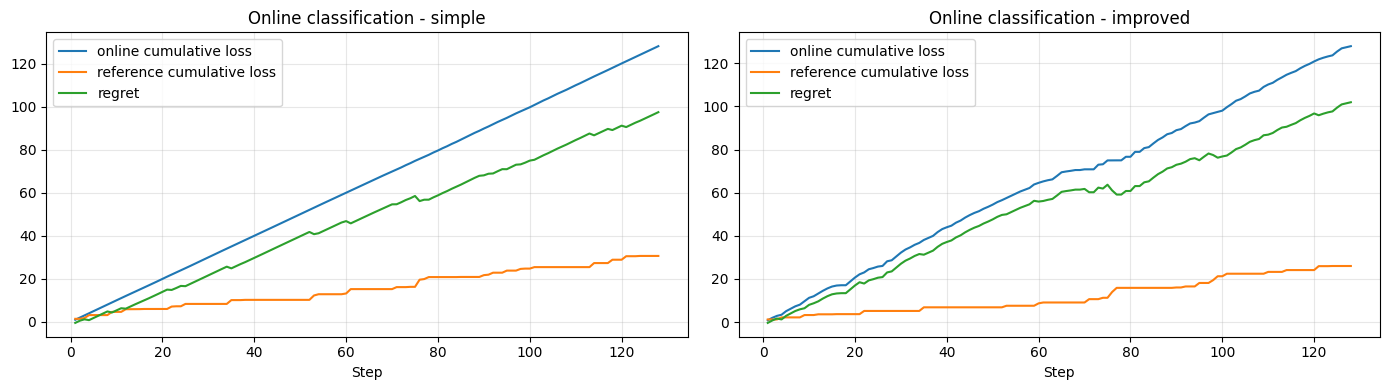

In [7]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, item in zip(axes, online_classification_results):
    history = item['history']
    ax.plot(history['step'], history['cumulative_loss'], label='online cumulative loss')
    ax.plot(history['step'], history['cumulative_reference_loss'], label='reference cumulative loss')
    ax.plot(history['step'], history['regret'], label='regret')
    ax.set_title(f"Online classification - {item['model']}")
    ax.set_xlabel('Step')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()


##  Gradient stochastique en regression

On compare: 
- **point unique** vs **mini-lot**;
- **pas constant** vs **pas decroissant**;
- **ordre fixe** vs **ordre aleatoire**.

La cellule suivante explore toutes ces combinaisons sur `CNN1` et `CNN2`.


In [8]:
stochastic_regression_results = []
regression_setups = [
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 1e-3},
]

for model_name in MODEL_NAMES:
    for setup in regression_setups:
        print(f"[stochastic regression] model={model_name} setup={setup}")
        result = run_stochastic_experiment(
            task='regression',
            model_name=model_name,
            epochs=STOCHASTIC_EPOCHS,
            **setup,
        )
        stochastic_regression_results.append(result)

stochastic_regression_summary = summarize_stochastic(stochastic_regression_results, task='regression')
stochastic_regression_summary.sort_values(['model', 'test_rmse']).reset_index(drop=True)


[stochastic regression] model=simple setup={'batch_size': 1, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 1, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 1, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 1, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 32, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 32, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 32, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 0.001}
[stochastic regression] model=simple setup={'batch_size': 32, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 0.001}
[stochastic regression] model=improved setup={'batch

,model,batch_size,lr_mode,order,base_lr,final_val_loss,test_loss,final_val_rmse,test_rmse,test_r2
0,improved,1,decay,fixed,0.001,30.380083,29.839587,5.511813,5.462562,8.575219e-02
1,improved,32,constant,random,0.001,31.350694,31.121458,5.599169,5.578661,4.647720e-02
2,improved,32,decay,random,0.001,32.067859,31.778242,5.662849,5.637219,2.635419e-02
3,improved,1,constant,fixed,0.001,34.001434,32.638393,5.831075,5.713002,2.384186e-07
4,improved,1,decay,random,0.001,34.034873,32.655906,5.833941,5.714535,-5.363226e-04
5,improved,1,constant,random,0.001,34.038391,32.658327,5.834243,5.714746,-6.104708e-04
6,improved,32,constant,fixed,0.001,37.877254,36.278056,6.154450,6.023127,-1.115144e-01
7,improved,32,decay,fixed,0.001,50.058982,48.207150,7.075237,6.943137,-4.770070e-01
8,simple,1,decay,fixed,0.001,34.049993,32.723635,5.835237,5.720457,-2.611399e-03
9,simple,1,decay,random,0.001,34.297941,32.886511,5.856445,5.734676,-7.601857e-03


,model,batch_size,lr_mode,order,base_lr,final_val_loss,test_loss,final_val_rmse,test_rmse,test_r2
0,improved,1,decay,fixed,0.001,30.380083,29.839587,5.511813,5.462562,8.575219e-02
1,improved,32,constant,random,0.001,31.350694,31.121458,5.599169,5.578661,4.647720e-02
2,improved,32,decay,random,0.001,32.067859,31.778242,5.662849,5.637219,2.635419e-02
3,improved,1,constant,fixed,0.001,34.001434,32.638393,5.831075,5.713002,2.384186e-07
4,improved,1,decay,random,0.001,34.034873,32.655906,5.833941,5.714535,-5.363226e-04
5,improved,1,constant,random,0.001,34.038391,32.658327,5.834243,5.714746,-6.104708e-04
6,improved,32,constant,fixed,0.001,37.877254,36.278056,6.154450,6.023127,-1.115144e-01
7,improved,32,decay,fixed,0.001,50.058982,48.207150,7.075237,6.943137,-4.770070e-01
8,simple,1,decay,fixed,0.001,34.049993,32.723635,5.835237,5.720457,-2.611399e-03
9,simple,1,decay,random,0.001,34.297941,32.886511,5.856445,5.734676,-7.601857e-03


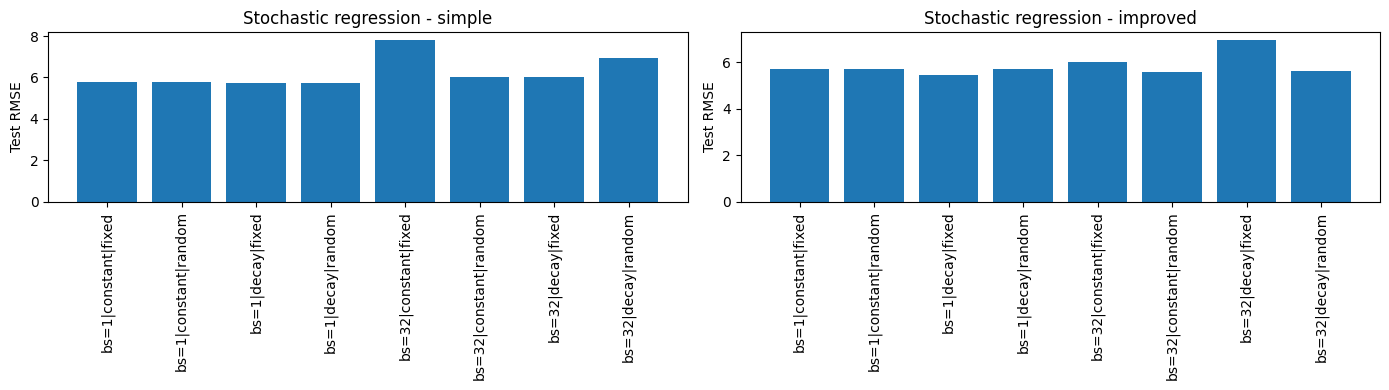

In [9]:
display(stochastic_regression_summary.sort_values(['model', 'test_rmse']).reset_index(drop=True))

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, model_name in zip(axes, MODEL_NAMES):
    subset = stochastic_regression_summary[stochastic_regression_summary['model'] == model_name]
    labels = [f"bs={row.batch_size}|{row.lr_mode}|{row.order}" for row in subset.itertuples()]
    ax.bar(labels, subset['test_rmse'])
    ax.set_title(f'Stochastic regression - {model_name}')
    ax.set_ylabel('Test RMSE')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()


##  Sous-gradient stochastique en classification

On fait la meme comparaison en classification binaire avec la perte hinge. Le critere principal de qualite sera ici le `F1` et l'accuracy sur validation et test.


In [10]:
stochastic_classification_results = []
classification_setups = [
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': POINT_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 1e-3},
    {'batch_size': MINI_BATCH_SIZE, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 1e-3},
]

for model_name in MODEL_NAMES:
    for setup in classification_setups:
        print(f"[stochastic classification] model={model_name} setup={setup}")
        result = run_stochastic_experiment(
            task='classification',
            model_name=model_name,
            epochs=STOCHASTIC_EPOCHS,
            **setup,
        )
        stochastic_classification_results.append(result)

stochastic_classification_summary = summarize_stochastic(stochastic_classification_results, task='classification')
stochastic_classification_summary.sort_values(['model', 'test_f1'], ascending=[True, False]).reset_index(drop=True)


[stochastic classification] model=simple setup={'batch_size': 1, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 1, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 1, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 1, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 32, 'lr_mode': 'constant', 'shuffle': False, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 32, 'lr_mode': 'constant', 'shuffle': True, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 32, 'lr_mode': 'decay', 'shuffle': False, 'base_lr': 0.001}
[stochastic classification] model=simple setup={'batch_size': 32, 'lr_mode': 'decay', 'shuffle': True, 'base_lr': 0.001}
[stochastic classifi

,model,batch_size,lr_mode,order,base_lr,final_val_loss,test_loss,final_val_f1,test_f1,test_accuracy
0,improved,1,decay,random,0.001,0.200313,0.208357,0.904762,0.906459,0.916
1,improved,1,constant,fixed,0.001,0.207919,0.230698,0.912281,0.896034,0.903
2,improved,1,constant,random,0.001,0.203408,0.221299,0.905125,0.889138,0.901
3,improved,1,decay,fixed,0.001,0.198334,0.235996,0.919614,0.885650,0.898
4,improved,32,constant,fixed,0.001,0.542579,0.584900,0.782953,0.757039,0.767
5,improved,32,decay,fixed,0.001,0.625361,0.672378,0.738072,0.702479,0.712
6,improved,32,constant,random,0.001,0.548777,0.597722,0.753129,0.693683,0.743
7,improved,32,decay,random,0.001,0.628531,0.678136,0.715719,0.666667,0.719
8,simple,1,decay,fixed,0.001,0.288290,0.298832,0.876068,0.875817,0.886
9,simple,1,constant,fixed,0.001,0.266251,0.280064,0.890295,0.875136,0.885


,model,batch_size,lr_mode,order,base_lr,final_val_loss,test_loss,final_val_f1,test_f1,test_accuracy
0,improved,1,decay,random,0.001,0.200313,0.208357,0.904762,0.906459,0.916
1,improved,1,constant,fixed,0.001,0.207919,0.230698,0.912281,0.896034,0.903
2,improved,1,constant,random,0.001,0.203408,0.221299,0.905125,0.889138,0.901
3,improved,1,decay,fixed,0.001,0.198334,0.235996,0.919614,0.885650,0.898
4,improved,32,constant,fixed,0.001,0.542579,0.584900,0.782953,0.757039,0.767
5,improved,32,decay,fixed,0.001,0.625361,0.672378,0.738072,0.702479,0.712
6,improved,32,constant,random,0.001,0.548777,0.597722,0.753129,0.693683,0.743
7,improved,32,decay,random,0.001,0.628531,0.678136,0.715719,0.666667,0.719
8,simple,1,decay,fixed,0.001,0.288290,0.298832,0.876068,0.875817,0.886
9,simple,1,constant,fixed,0.001,0.266251,0.280064,0.890295,0.875136,0.885


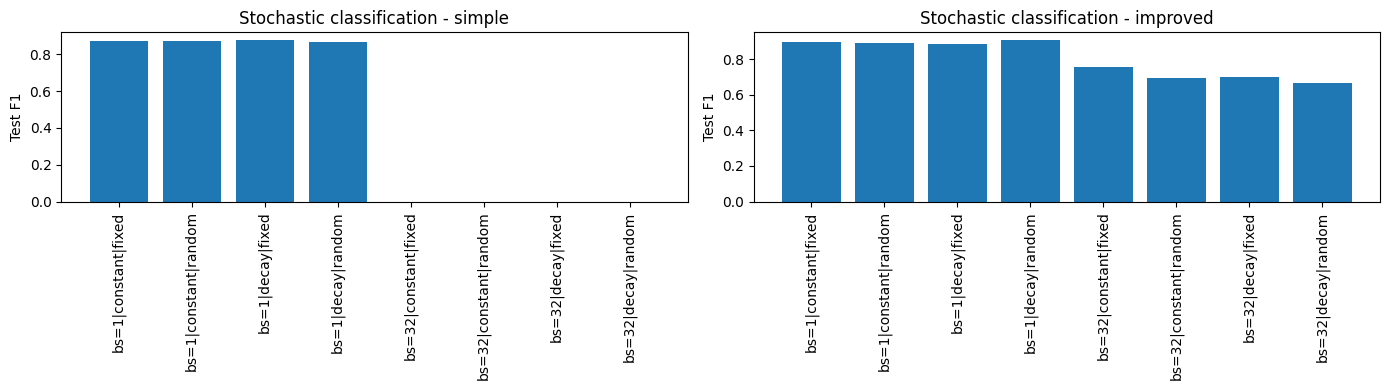

In [11]:
display(stochastic_classification_summary.sort_values(['model', 'test_f1'], ascending=[True, False]).reset_index(drop=True))

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(14, 4), sharey=False)

for ax, model_name in zip(axes, MODEL_NAMES):
    subset = stochastic_classification_summary[stochastic_classification_summary['model'] == model_name]
    labels = [f"bs={row.batch_size}|{row.lr_mode}|{row.order}" for row in subset.itertuples()]
    ax.bar(labels, subset['test_f1'])
    ax.set_title(f'Stochastic classification - {model_name}')
    ax.set_ylabel('Test F1')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
